In [18]:
from bpd.io import load_dataset
import jax.numpy as jnp
from jax import jit
from bpd.prior import ellip_prior_e1e2
import jax.scipy as jsp

from jax import Array, grad, vmap
from jax.numpy.linalg import norm
from jax.scipy import stats

from functools import partial

import jax 
from bpd.utils import uniform_logpdf

from bpd.chains import run_inference_nuts

import matplotlib.pyplot as plt 

In [2]:


from bpd.shear import (
    inv_shear_func1,
    inv_shear_func2,
    inv_shear_transformation,
)

_grad_fnc1 = vmap(vmap(grad(inv_shear_func1), in_axes=(0, None)), in_axes=(0, None))
_grad_fnc2 = vmap(vmap(grad(inv_shear_func2), in_axes=(0, None)), in_axes=(0, None))
_inv_shear_trans = vmap(inv_shear_transformation, in_axes=(0, None))

In [3]:
# use a modified version of BA2014 distribution for true prior, add m,c which are inferred jointly
# with shear



def true_ellip_logprior(e_post, g, *, sigma_e: float):
    """Implementation of GB's true prior on interim posterior samples of ellipticities."""

    # jacobian of inverse shear transformation
    grad1 = _grad_fnc1(e_post, g)
    grad2 = _grad_fnc2(e_post, g)
    absjacdet = jnp.abs(grad1[..., 0] * grad2[..., 1] - grad1[..., 1] * grad2[..., 0])

    # true prior on unsheared ellipticity
    e_post_unsheared = _inv_shear_trans(e_post, g)
    prior_val = ellip_prior_e1e2(e_post_unsheared, sigma=sigma_e)

    return jnp.log(prior_val) + jnp.log(absjacdet)

def shear_loglikelihood(
    g,
    post_params,
    *,
    logprior,
    interim_logprior
):
    """Shear Likelihood implementation of Schneider et al. 2014."""
    num = logprior(post_params, g)
    denom = interim_logprior(post_params)
    ratio = jsp.special.logsumexp(num - denom, axis=-1)
    return ratio.sum()

def logtarget(
    g,
    data,
    *,
    sigma_e:float,
    sigma_e_int: float,
):

    _logprior = lambda e, g: true_ellip_logprior(e, g, sigma_e=sigma_e)
    _interim_logprior = lambda e: jnp.log(ellip_prior_e1e2(e, sigma=sigma_e_int))

    loglike = shear_loglikelihood(g, e1e2, logprior=_logprior, interim_logprior=_interim_logprior)

    g_mag = jnp.sqrt(g[0] ** 2 + g[1] ** 2)
    logprior_g = uniform_logpdf(g_mag, 0.0, 1.0) + jnp.log(1 / (2 * jnp.pi))


    return loglike +logprior_g

In [4]:
def shear_pipeline(rng_key, init_positions, e1e2, *, logtarget):
    return run_inference_nuts(
        rng_key,
        data=e1e2,
        init_positions=init_positions,
        logtarget=_logtarget,
        n_samples=1000,
        n_warmup_steps=500,
        max_num_doublings=2,
        initial_step_size=1e-3,
    )

In [5]:
samples_file = "/pscratch/sd/i/imendoza/data/cache_chains/exp70_51/interim_samples_511_plus.npz"
ds = load_dataset(samples_file)

In [6]:
e1 = ds['samples']['e1']
e2 = ds['samples']['e2']
e1.shape

(320000, 300)

In [7]:
e1e2 = jnp.stack([e1,e2],axis=-1)
e1e2.shape

(320000, 300, 2)

In [8]:
_logtarget = partial(logtarget, sigma_e=0.2,sigma_e_int=0.3)

In [9]:

pipe = jit(partial(shear_pipeline,logtarget=_logtarget))

In [10]:
key = jax.random.key(42)
key

Array((), dtype=key<fry>) overlaying:
[ 0 42]

In [11]:
# init_positions = {'m': 0.0, 'c':0.0, 'g':jnp.array([0.02, 0.0]), 'sigma_e':0.2}

In [12]:
GPU = jax.devices("gpu")[0]
e1e2 = jax.device_put(e1e2, GPU)


In [13]:
# compile
_ = pipe(key, jnp.array([0.02, 0.0]), e1e2[:2])

In [14]:
samples = pipe(key, jnp.array([0.02, 0.0]), e1e2)

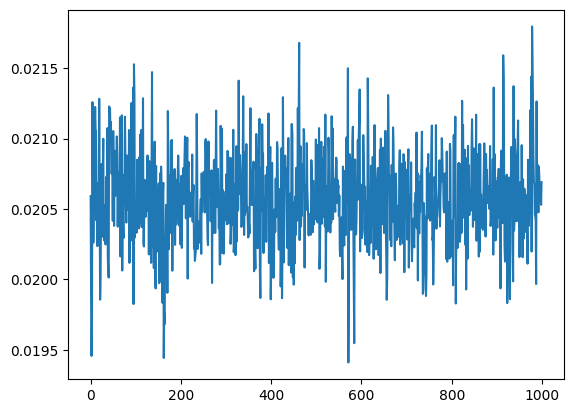

In [19]:
plt.plot(samples[:, 0])

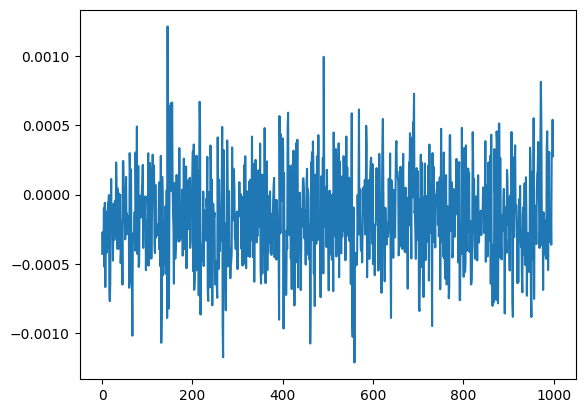

In [20]:
plt.plot(samples[:, 1])

In [24]:
0.0205 - 2*samples[:,0].std() 

Array(0.01984356, dtype=float64)